**1. Importing the dependencies**

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score,roc_auc_score,average_precision_score,confusion_matrix,classification_report
import pickle

**2. Data Loading and Understanding**

In [42]:
# load the csv data to a pandas dataframe
df = pd.read_csv("/workspaces/customer_churning/Telco-Customer-Churn.csv")

In [43]:
df.shape

(7043, 21)

In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
pd.set_option("display.max_columns", None)

In [46]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [48]:
# dropping customerID column as this is not required for modelling
df = df.drop(columns=["customerID"])

In [49]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [50]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [13]:
print(df["gender"].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [51]:
print(df["SeniorCitizen"].unique())

[0 1]


In [52]:
# printing the unique values in all the columns

# Identify numerical and categorical features

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    col for col in df.columns
    if col not in numerical_features
]

# Display unique values for each categorical feature

for col in categorical_features:
    print(f"{col}")
    print(f"Unique values: {df[col].unique()}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("-" * 70)

gender
Unique values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Number of unique values: 2
----------------------------------------------------------------------
SeniorCitizen
Unique values: [0 1]
Number of unique values: 2
----------------------------------------------------------------------
Partner
Unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Number of unique values: 2
----------------------------------------------------------------------
Dependents
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2
----------------------------------------------------------------------
PhoneService
Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Number of unique values: 2
----------------------------------------------------------------------
MultipleLines
Unique values: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Number of unique values: 3
---------------------------------------------

### Unique Values in Categorical Features

Before preprocessing the dataset, we examine the unique values present in each categorical feature. This helps us understand the structure of the data and identify any unexpected or inconsistent values.

In [53]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [54]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [55]:
# Verify there are no missing values
print(df["TotalCharges"].isna().sum())

0


In [56]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [57]:
print(df["Churn"].unique())
print(df["Churn"].isna().sum())

[0 1]
0


Imbalanced Dataset 
Check if the the datatset is balanced to prevent it from favouring a particular value

In [59]:
# checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Insights:**
1. Customer ID removed as it is not required for modelling
2. No missing values in the dataset
3. Missing values in the TotalCharges column were replaced with the median value
4. Class imbalance identified in the target

**3. Exploratory Data Analysis (EDA)**

In [23]:
df.shape

(7043, 20)

In [60]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [25]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [26]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


**Numerical Features - Analysis**

Understand the distribution of teh numerical features

In [62]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

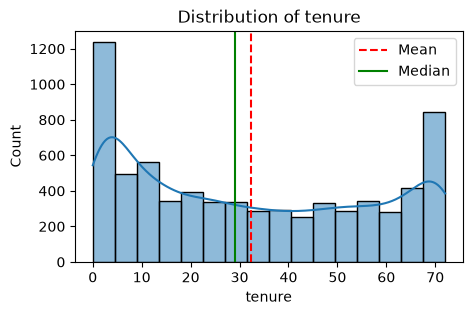

In [28]:
plot_histogram(df, "tenure")

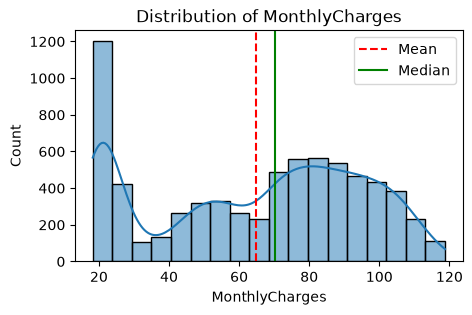

In [29]:
plot_histogram(df, "MonthlyCharges")

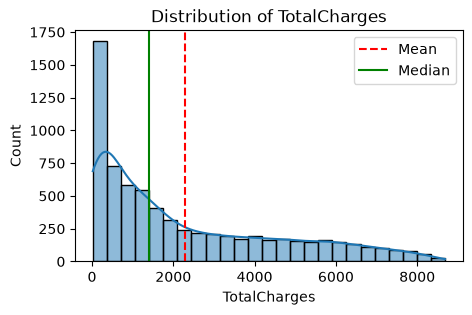

In [30]:
plot_histogram(df, "TotalCharges")

**Box plot for numerical features**

In [31]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

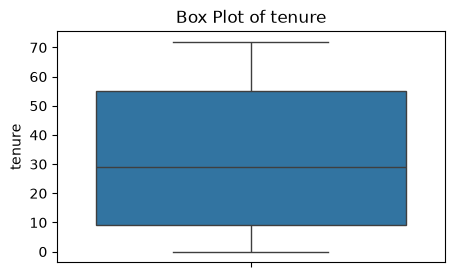

In [32]:
plot_boxplot(df, "tenure")

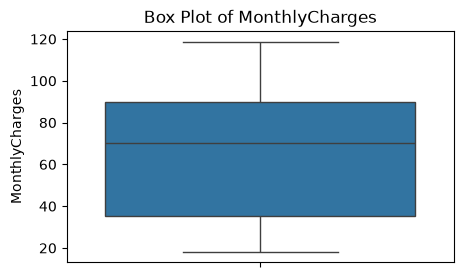

In [33]:
plot_boxplot(df, "MonthlyCharges")

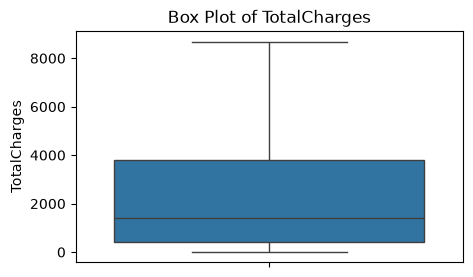

In [34]:
plot_boxplot(df, "TotalCharges")

**Correlation Heatmap for numerical columns**

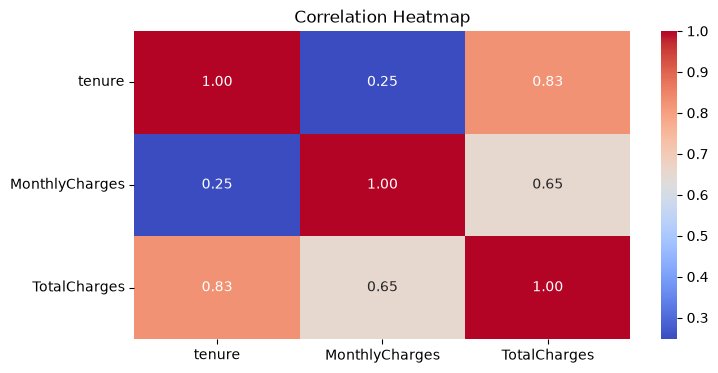

In [35]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Categorical features - Analysis

In [63]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Countplot for categorical columns

/tmp/ipykernel_8070/1836195783.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include="object").columns.to_list()


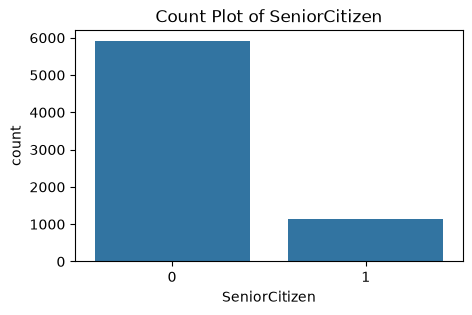

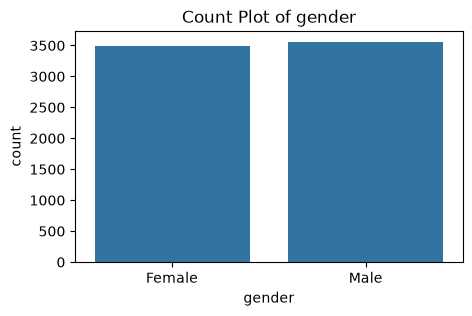

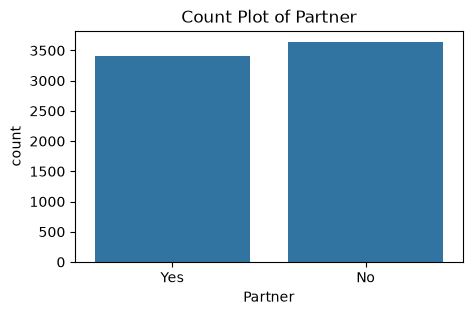

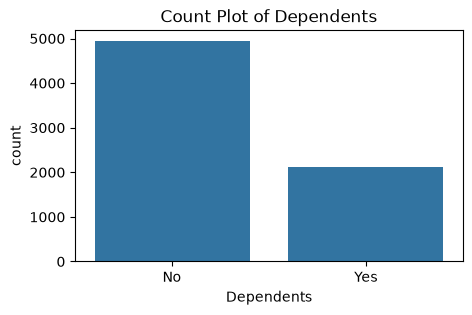

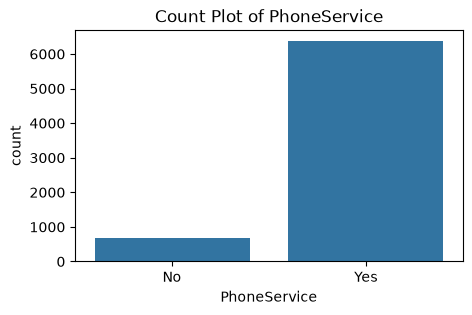

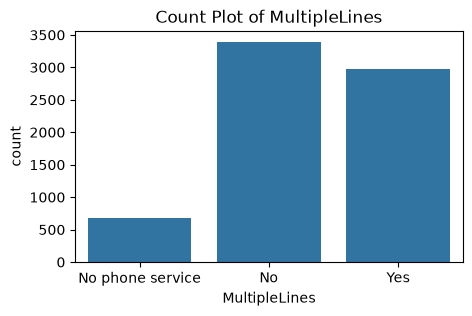

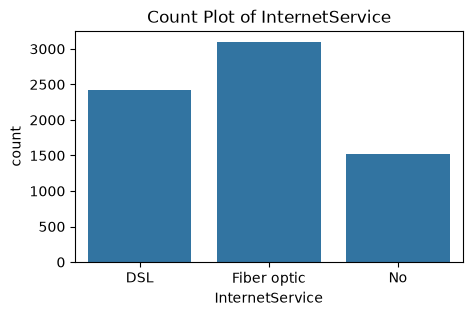

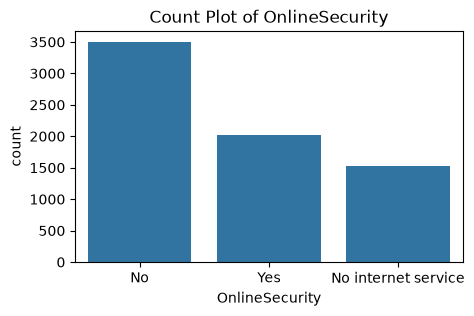

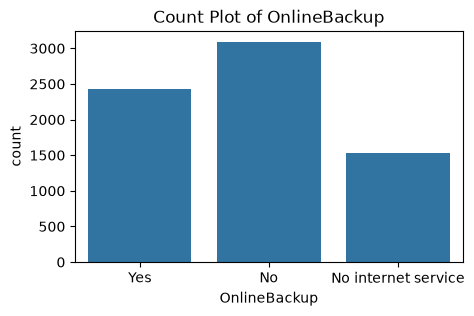

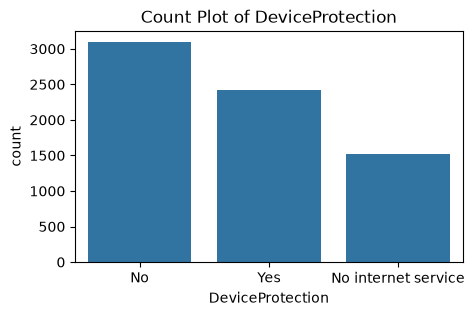

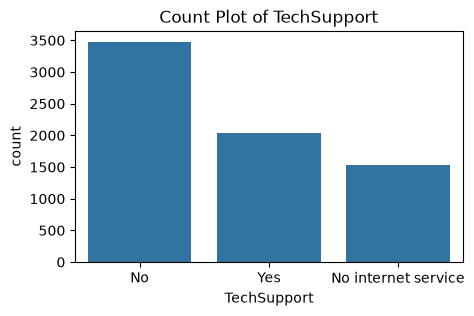

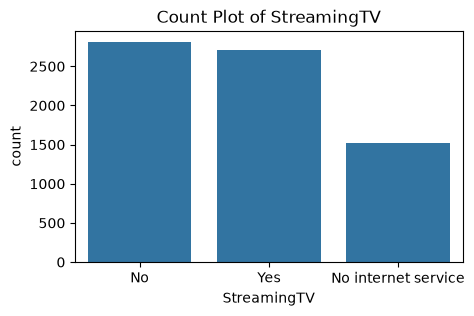

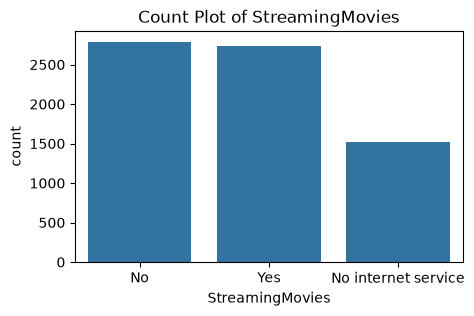

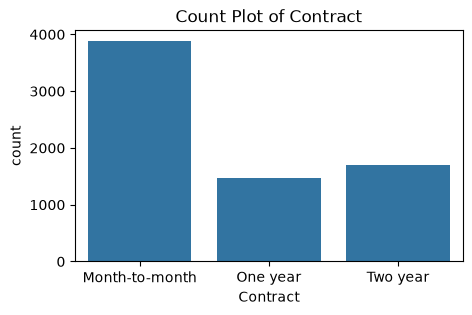

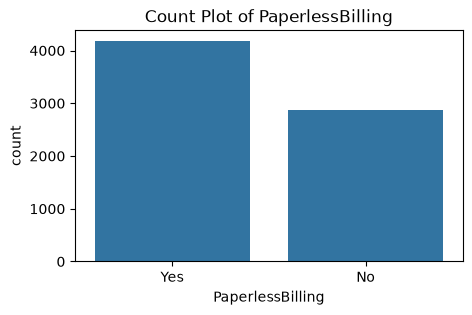

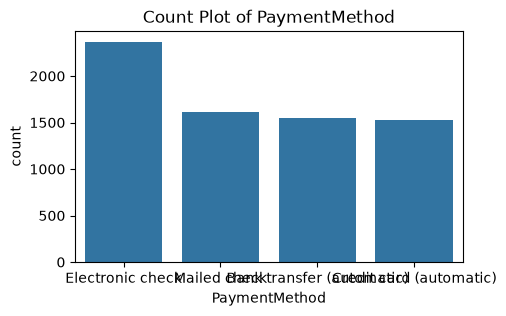

In [64]:
object_cols = df.select_dtypes(include="object").columns.to_list()

if "SeniorCitizen" not in object_cols:
    object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.show()

**4. Data Preprocessing**

In [65]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Define numerical features
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Define categorical features
categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nChurn included in categorical features?",
      "Churn" in categorical_features)

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Churn included in categorical features? False


**Traianing and test data split**

In [67]:
# Remove customerID from the features
X = df.drop(["Churn"], axis=1)
y = df["Churn"]

# Numerical features
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Categorical features
categorical_features = [
    col for col in X.columns
    if col not in numerical_features
]

# Verify
print("Churn in X:", "Churn" in X.columns)
print("CustomerID in X:", "customerID" in X.columns)
print("Churn in categorical features:", "Churn" in categorical_features)

print("\nNumerical:", numerical_features)
print("\nCategorical:", categorical_features)

Churn in X: False
CustomerID in X: False
Churn in categorical features: False

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify
print("y values:", y.unique())
print("y_train values:", y_train.unique())
print("y_test values:", y_test.unique())

y values: [0 1]
y_train values: [0 1]
y_test values: [0 1]


Create the ColumnTransformer

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

Synthetic Minority Oversampling TEchnique (SMOTE)

In [70]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def make_pipeline(model):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

**5. Model Training**

Training with default hyperparameters

In [71]:
models_pipeline = {
    "Decision Tree": make_pipeline(
        DecisionTreeClassifier(random_state=42)
    ),

    "Random Forest": make_pipeline(
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    ),

    "XGBoost": make_pipeline(
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
}

In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

churn_f1 = make_scorer(
    f1_score,
    pos_label=1
)

cv_scores = {}

for model_name, model in models_pipeline.items():

    print(f"Training {model_name}")

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=churn_f1,
        n_jobs=-1
    )

    cv_scores[model_name] = scores

    print(
        f"{model_name} CV Churn F1: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

    print("-" * 60)

Training Decision Tree


Decision Tree CV Churn F1: 0.483 ± 0.024
------------------------------------------------------------
Training Random Forest
Random Forest CV Churn F1: 0.545 ± 0.022
------------------------------------------------------------
Training XGBoost
XGBoost CV Churn F1: 0.565 ± 0.024
------------------------------------------------------------


In [73]:
cv_scores

{'Decision Tree': array([0.4852459 , 0.47603306, 0.48896435, 0.44518272, 0.51851852]),
 'Random Forest': array([0.52877698, 0.52238806, 0.56989247, 0.53211009, 0.57251908]),
 'XGBoost': array([0.53141831, 0.54382826, 0.5940246 , 0.58143608, 0.57614679])}

Random Forest and XGBoost achieved the highest cross-validated F1 scores, with XGBoost performing best

**6.RANDOM FOREST**

In [74]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = models_pipeline["Random Forest"]

rf_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [None, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=10,              # much faster
    scoring=churn_f1,
    cv=3,                   # 3-fold for tuning
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV Churn F1:")
print(rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}

Best CV Churn F1:
0.6152516551949742


In [75]:
best_rf = rf_search.best_estimator_

y_test_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Accuracy : 0.7750177430801988
Recall   : 0.6122994652406417
F1 Score : 0.5909677419354838
ROC-AUC  : 0.835312201296856
PR-AUC   : 0.6285165952138538

Confusion Matrix:
[[863 172]
 [145 229]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.61      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



**7.XGBOOST**

In [ ]:
xgb_pipeline = models_pipeline["XGBoost"]

xgb_params = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring=churn_f1,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV Churn F1:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

Best CV Churn F1:
0.6286681743900034


In [ ]:
best_xgb = xgb_search.best_estimator_

y_test_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Accuracy : 0.7700496806245565
Recall   : 0.679144385026738
F1 Score : 0.6105769230769231
ROC-AUC  : 0.8383050453382934
PR-AUC   : 0.6396977615358781

Confusion Matrix:
[[831 204]
 [120 254]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [ ]:
# Get the best tuned XGBoost pipeline
best_xgb = xgb_search.best_estimator_

# Get the preprocessing step
preprocessor = best_xgb.named_steps["preprocessor"]

# Get the XGBoost model
xgb_model = best_xgb.named_steps["model"]

# Get feature names after OneHotEncoder
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 46


**8.FEATURE IMPORTANCE**

cat__Contract_Month-to-month           0.214104
cat__OnlineSecurity_Yes                0.094005
cat__TechSupport_Yes                   0.087244
cat__TechSupport_No                    0.083662
cat__OnlineSecurity_No                 0.076297
cat__PaymentMethod_Electronic check    0.066417
cat__OnlineBackup_No                   0.055181
cat__PaperlessBilling_No               0.042001
cat__Dependents_No                     0.040032
cat__StreamingTV_Yes                   0.029835
num__tenure                            0.025972
cat__InternetService_Fiber optic       0.024849
cat__Partner_No                        0.022058
num__TotalCharges                      0.018633
cat__DeviceProtection_No               0.015177
dtype: float32


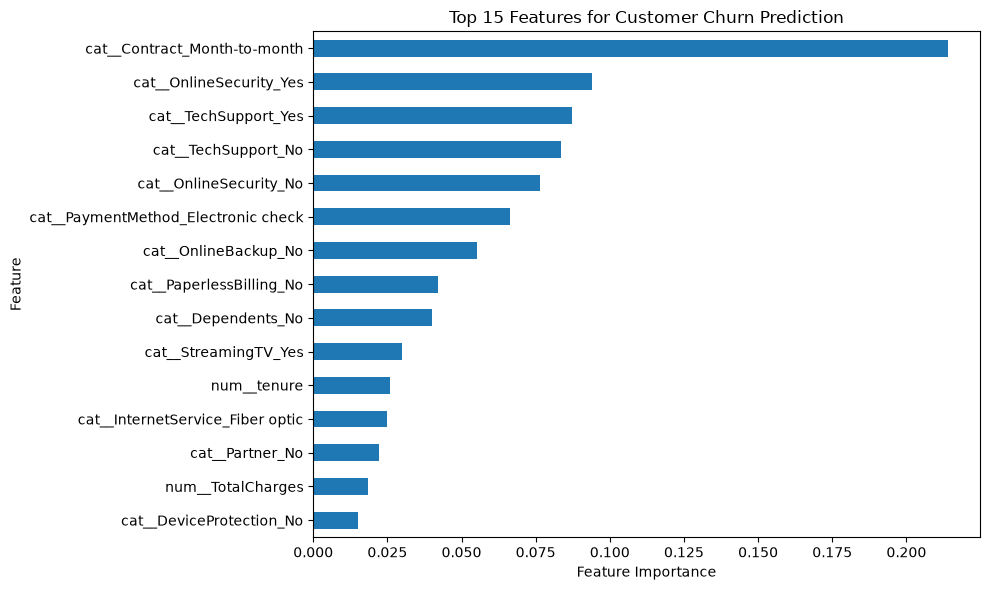

In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(15))
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features for Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
print(y_test.value_counts())

Churn
0    1035
1     374
Name: count, dtype: int64


**SHAP**
stands for SHapley Additive exPlanations.

In simple terms, SHAP explains why a machine-learning model made a particular prediction.

In [ ]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


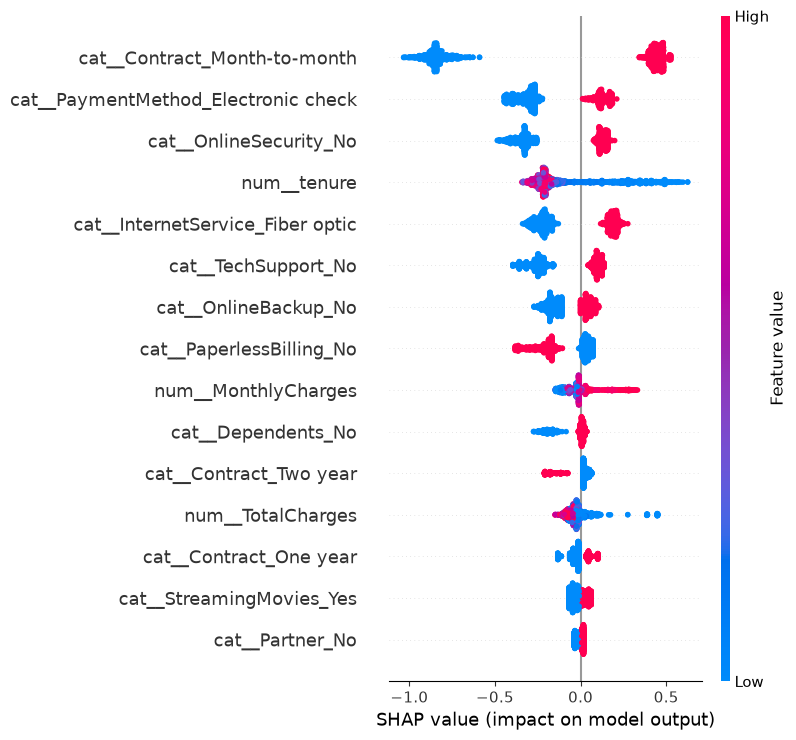

In [ ]:
import shap
X_test_transformed = preprocessor.transform(X_test)

# Convert to DataFrame for readable SHAP plots
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed_df)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    max_display=15
)

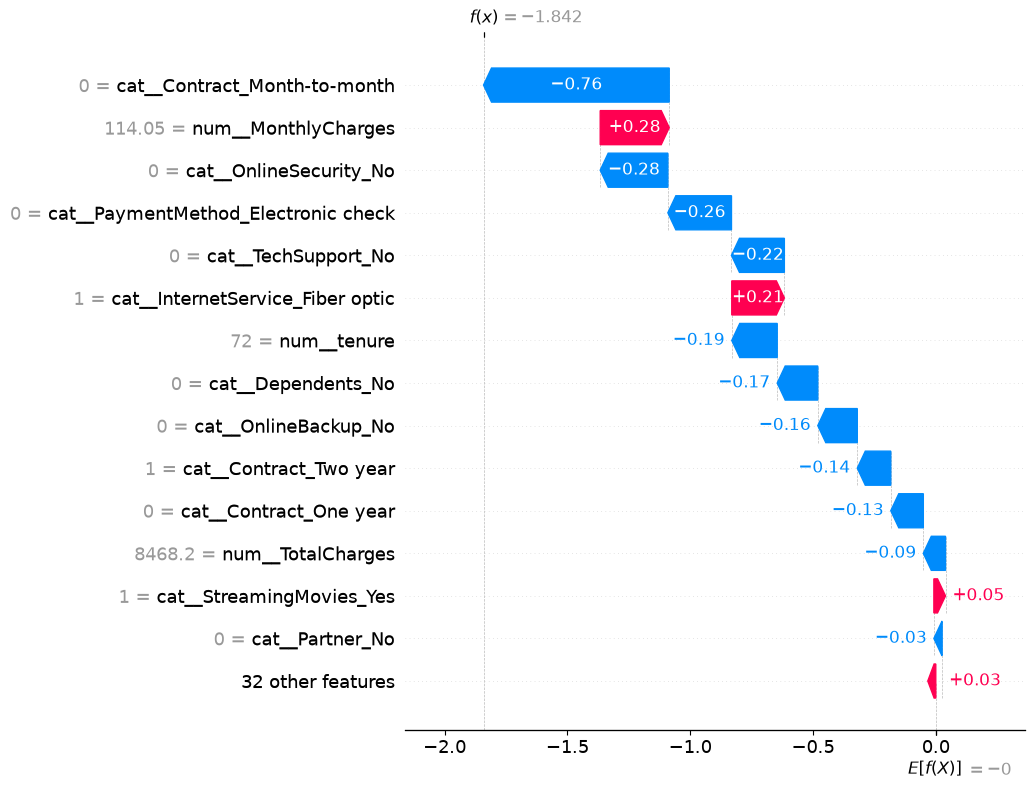

In [ ]:
customer_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_index],
        base_values=explainer.expected_value,
        data=X_test_transformed_df.iloc[customer_index],
        feature_names=feature_names
    ),
    max_display=15
)

**9. Model Loading**

In [ ]:
# Save the final tuned XGBoost pipeline

model_data = {
    "model": best_xgb
}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved successfully!")

Model saved successfully!


**10. Load the saved  model and  build a Predictive System**

In [ ]:
# Load the saved model

with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                    

In [ ]:
# Customer data
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

# Convert to DataFrame
input_data_df = pd.DataFrame([input_data])

# Make prediction using the COMPLETE pipeline
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)[:, 1]

# Display result
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Churn Probability: {pred_prob[0]:.2%}")

Prediction: Churn
Churn Probability: 68.70%
